In [ ]:
!pip install nltk scikit-learn pandas gensim tensorflow

In [ ]:
import pandas as pd
import numpy as np
import nltk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from gensim.models import Word2Vec
import tensorflow as tf

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')  # change name if needed
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
# ==============================
# STEP 4: BAG OF WORDS + SVM
# ==============================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from time import time

# ------------------------------
# Vectorization (Bag of Words)
# ------------------------------
start_time = time()

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

end_time = time()
bow_time = end_time - start_time

print("BoW Vectorization Time:", bow_time)


# ------------------------------
# Model Training (Fast SVM)
# ------------------------------
model_bow = LinearSVC()
model_bow.fit(X_train_bow, y_train)


# ------------------------------
# Predictions
# ------------------------------
y_pred_bow = model_bow.predict(X_test_bow)


# ------------------------------
# Evaluation
# ------------------------------
accuracy_bow = accuracy_score(y_test, y_pred_bow)

print("\n===== BoW + SVM Results =====")
print("Accuracy:", accuracy_bow)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bow))

BoW Vectorization Time: 5.667079925537109

===== BoW + SVM Results =====
Accuracy: 0.862

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4961
           1       0.86      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [ ]:
# ==============================
# STEP 5: TF-IDF + SVM
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from time import time

# ------------------------------
# Vectorization (TF-IDF)
# ------------------------------
start_time = time()

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

end_time = time()
tfidf_time = end_time - start_time

print("TF-IDF Vectorization Time:", tfidf_time)


# ------------------------------
# Model Training
# ------------------------------
model_tfidf = LinearSVC()
model_tfidf.fit(X_train_tfidf, y_train)


# ------------------------------
# Predictions
# ------------------------------
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)


# ------------------------------
# Evaluation
# ------------------------------
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("\n===== TF-IDF + SVM Results =====")
print("Accuracy:", accuracy_tfidf)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tfidf))

TF-IDF Vectorization Time: 17.532836198806763

===== TF-IDF + SVM Results =====
Accuracy: 0.8814

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
tokenized_X_train = [text.split() for text in X_train]
tokenized_X_test = [text.split() for text in X_test]

In [ ]:
from gensim.models import Word2Vec
from time import time

start_time = time()

w2v_model = Word2Vec(
    sentences=tokenized_X_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

end_time = time()
w2v_time = end_time - start_time

print("Word2Vec Training Time:", w2v_time)

Word2Vec Training Time: 85.86993622779846


In [ ]:
import numpy as np

def get_sentence_vector(words, model):
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_train_w2v = np.array([get_sentence_vector(words, w2v_model) for words in tokenized_X_train])
X_test_w2v = np.array([get_sentence_vector(words, w2v_model) for words in tokenized_X_test])

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_nn.fit(X_train_w2v, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8403 - loss: 0.3681 - val_accuracy: 0.8560 - val_loss: 0.3338
Epoch 2/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8544 - loss: 0.3365 - val_accuracy: 0.8650 - val_loss: 0.3185
Epoch 3/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8583 - loss: 0.3301 - val_accuracy: 0.8630 - val_loss: 0.3210
Epoch 4/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8616 - loss: 0.3249 - val_accuracy: 0.8652 - val_loss: 0.3206
Epoch 5/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8631 - loss: 0.3209 - val_accuracy: 0.8702 - val_loss: 0.3093


In [ ]:
loss, accuracy_w2v = model_nn.evaluate(X_test_w2v, y_test)

print("Word2Vec + NN Accuracy:", accuracy_w2v)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8580 - loss: 0.3234
Word2Vec + NN Accuracy: 0.8579999804496765


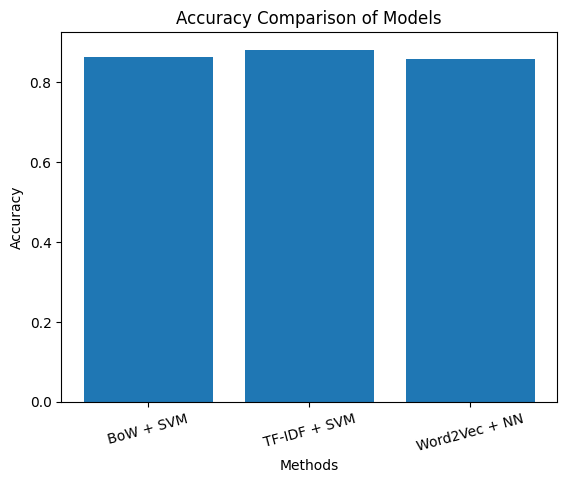

In [ ]:
import matplotlib.pyplot as plt

# Data
methods = ['BoW + SVM', 'TF-IDF + SVM', 'Word2Vec + NN']
accuracy = [0.862, 0.8814, 0.858]

# Plot
plt.figure()
plt.bar(methods, accuracy)
plt.title("Accuracy Comparison of Models")
plt.xlabel("Methods")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()


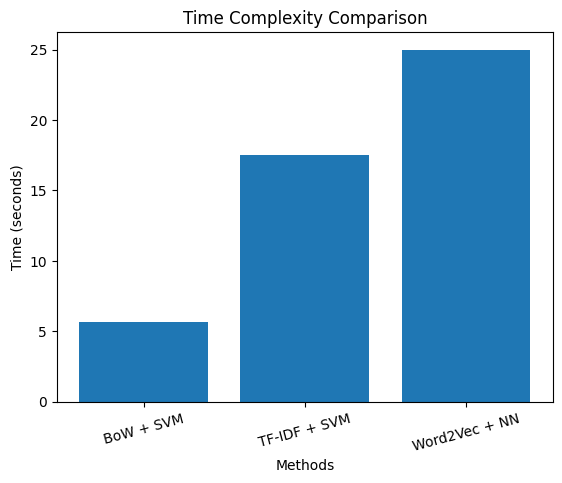

In [ ]:
# Time values (use your actual values)
times = [5.67, 17.53, 25]  # approx for Word2Vec

plt.figure()
plt.bar(methods, times)
plt.title("Time Complexity Comparison")
plt.xlabel("Methods")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=15)

plt.show()

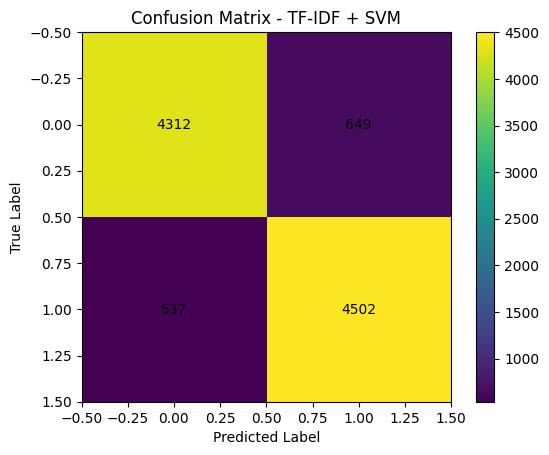

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tfidf)

# Plot Heatmap (without seaborn)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix - TF-IDF + SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

# Add values inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()
